c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints
Device: cuda
Student usato per saliency: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000
Test columns: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids']
Num test rows: 31344

=== REVIEW 1 (auto-selezionata dal test set) ===
Dataset index: 2
Teacher: {'pred': 1, 'prob_no_spoiler': 0.1575605720281601, 'prob_spoiler': 0.8424394726753235}
Student: {'pred': 1, 'prob_no_spoiler': 0.25034862756729126, 'prob_spoiler': 0.7496513724327087}
Testo (troncato ai primi 1200 caratteri per display):
when watching the general ( 1926 ), the similarities between buster keaton and charlie chaplin are almost unmistakable. the story was original and humorous and the performance by buster keaton was pleasing. what i didn't

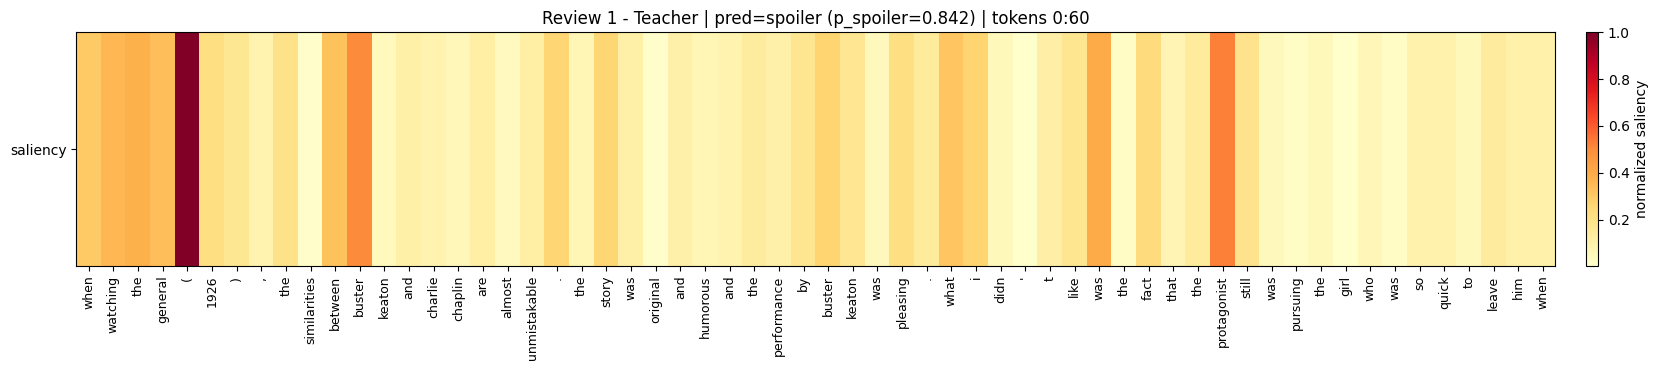

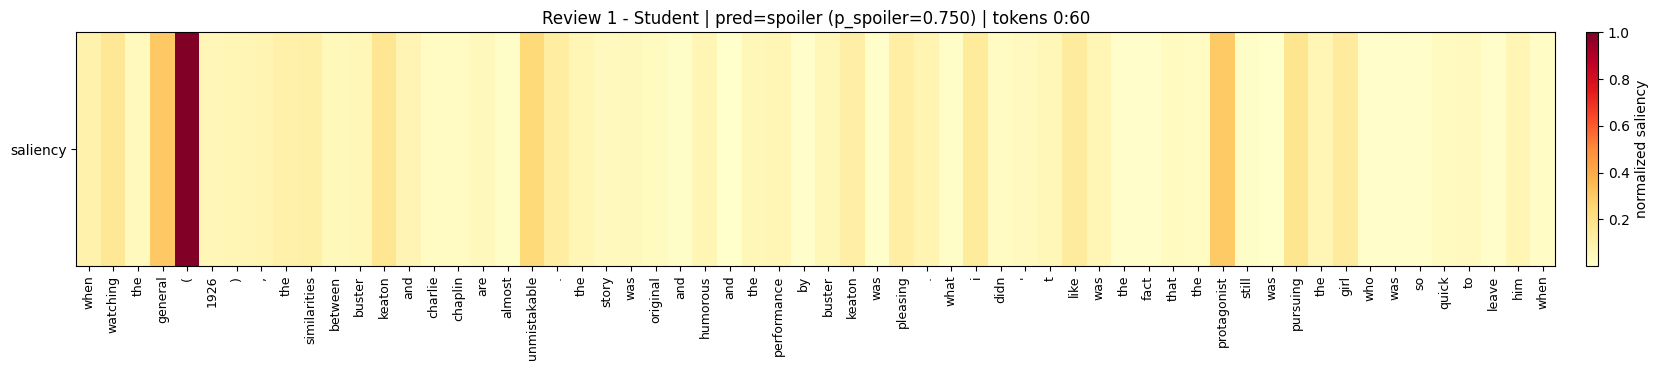


[Review 1] Teacher
Top-10 token più salienti:
                ( -> 1.0000
            gives -> 0.6758
      protagonist -> 0.5262
           buster -> 0.5023
              was -> 0.3983
              the -> 0.3783
         watching -> 0.3573
          general -> 0.3370
          between -> 0.3250
             what -> 0.3160

[Review 1] Student
Top-10 token più salienti:
                ( -> 1.0000
              the -> 0.5261
              end -> 0.4464
          general -> 0.3042
      protagonist -> 0.2992
            train -> 0.2926
            falls -> 0.2429
     unmistakable -> 0.2399
              her -> 0.2364
           scenes -> 0.2070

=== REVIEW 2 (tricky, incollata manualmente) ===
Teacher: {'pred': 1, 'prob_no_spoiler': 0.2680358588695526, 'prob_spoiler': 0.7319641709327698}
Student: {'pred': 1, 'prob_no_spoiler': 0.4290177822113037, 'prob_spoiler': 0.5709822177886963}


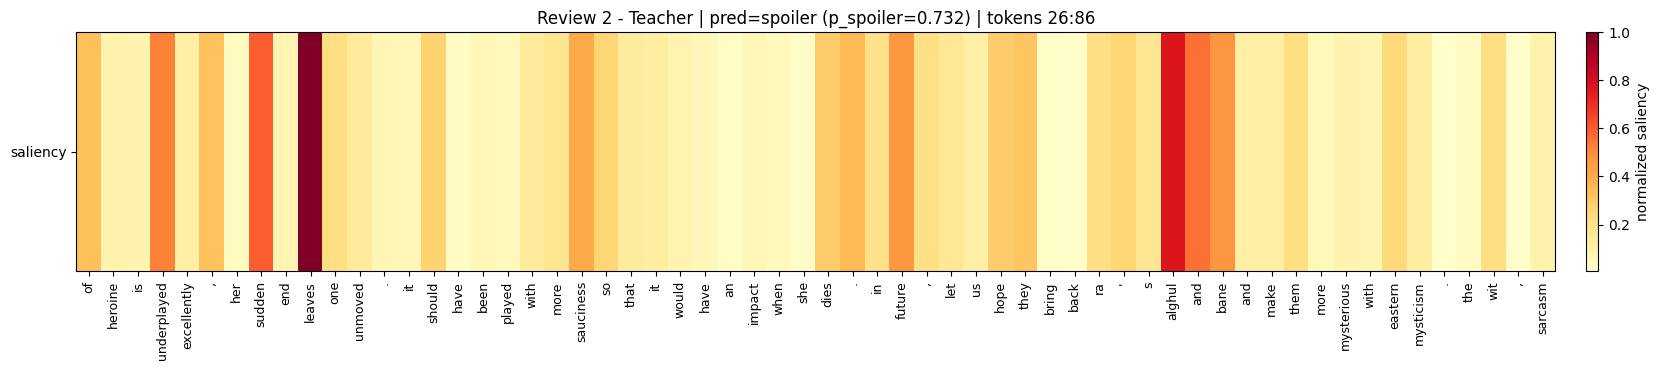

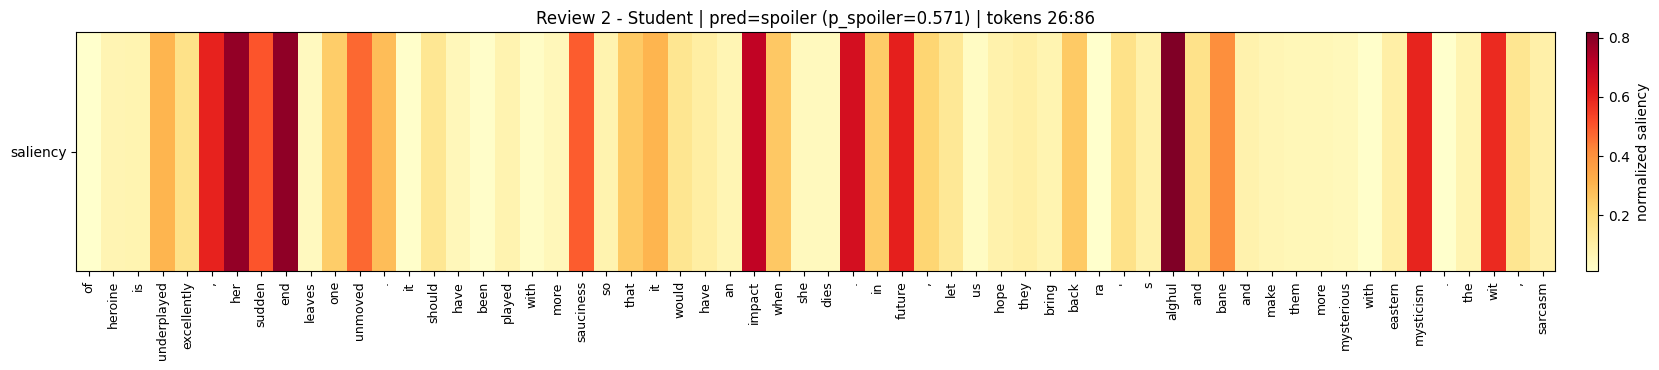


[Review 2] Quota di saliency sulle keyword tricky
Teacher: 0.0160
Student: 0.0019

[Review 2] Teacher
Top-10 token più salienti:
           leaves -> 1.0000
           alghul -> 0.7728
           sudden -> 0.5962
              and -> 0.5603
      underplayed -> 0.5233
            joker -> 0.4944
             bane -> 0.4703
           future -> 0.4662
        sauciness -> 0.4041
                . -> 0.3527

[Review 2] Student
Top-10 token più salienti:
           ledger -> 1.0000
           alghul -> 0.8185
              end -> 0.7924
              her -> 0.7865
           impact -> 0.7028
                . -> 0.6563
           future -> 0.6047
            heath -> 0.6044
                , -> 0.6005
        mysticism -> 0.5967

Figure salvate in: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\reports\figures\saliency_maps


In [1]:
# =========================
# Saliency maps: teacher vs student
# - Review 1: spoiler correttamente classificata da entrambi (scelta automaticamente dal test set)
# - Review 2: review "tricky" con parola/e tipo "die", incollata manualmente
# =========================

import sys
import inspect
from pathlib import Path
from typing import Dict, Optional, Tuple, List

import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -------------------------------------------------
# Setup paths (coerente col tuo notebook/script)
# -------------------------------------------------
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
phase1_ckpt_path = CKPT_DIR / "tinybert_phase1" / "checkpoint-57856"
student_core_path = CKPT_DIR / "tinybert_phase1" / "student_base_final"
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

assert teacher_path.exists(), f"Non esiste: {teacher_path}"
assert phase1_ckpt_path.exists(), f"Non esiste: {phase1_ckpt_path}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

# -------------------------------------------------
# Caricamento modelli
# -------------------------------------------------
teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device).eval()

# Per le saliency del confronto teacher vs student uso lo student finale (phase 2),
# che è il modello di classificazione distillato finale.
# Fallback: se phase2 non esiste, provo col checkpoint phase1 (meno consigliato).
student_path_for_saliency = student_phase2_path if student_phase2_path.exists() else phase1_ckpt_path
print("Student usato per saliency:", student_path_for_saliency)

student = AutoModelForSequenceClassification.from_pretrained(student_path_for_saliency).to(device).eval()

# -------------------------------------------------
# Dataset test
# -------------------------------------------------
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
print("Test columns:", test_ds.column_names)
print("Num test rows:", len(test_ds))

if "label" in test_ds.column_names:
    LABEL_COL = "label"
elif "labels" in test_ds.column_names:
    LABEL_COL = "labels"
else:
    raise ValueError("Non trovo la colonna label/labels nel test parquet.")

# -------------------------------------------------
# Config
# -------------------------------------------------
MAX_LEN = 512
HEAD_KEEP = 128
TAIL_KEEP = 382
CLASS_NAMES = {0: "no spoiler", 1: "spoiler"}

# Per la review tricky puoi incollare il testo qui.
REVIEW_2_TEXT = "very good film.Apart from Heath ledger,the chasing sequence deserves an Oscar for stunt coordination.I thoroughly enjoyed this. The role of heroine is underplayed excellently,her sudden end leaves one unmoved.It should have been played with more sauciness so that it would have an impact when she dies.In future,let us hope they bring back Ra's Alghul and Bane and make them more mysterious with eastern mysticism.The wit,sarcasm and abrupt violence of Joker in this film acts like cathartic to the urban decay with which one is surrounded.overall,a very satisfying movie which is beginning to feel a lot more better than the graphic novels.I want to go back and see the film again and again.This is the best compliment one can pay."
# REVIEW_2_TEXT = """Incolla qui la review tricky con parole tipo 'die' ma senza spoiler reali."""

TRICKY_KEYWORDS = {"die", "dies", "died", "dead", "death", "kill", "killed", "murder"}

OUT_DIR = ROOT / "reports" / "figures" / "saliency_maps"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Utility
# -------------------------------------------------
def safe_forward(
    model,
    *,
    input_ids=None,
    inputs_embeds=None,
    attention_mask=None,
    token_type_ids=None,
):
    """
    Inoltra solo gli argomenti supportati dal forward del modello.
    """
    params = inspect.signature(model.forward).parameters
    kwargs = {}

    if input_ids is not None and "input_ids" in params:
        kwargs["input_ids"] = input_ids
    if inputs_embeds is not None and "inputs_embeds" in params:
        kwargs["inputs_embeds"] = inputs_embeds
    if attention_mask is not None and "attention_mask" in params:
        kwargs["attention_mask"] = attention_mask
    if token_type_ids is not None and "token_type_ids" in params:
        kwargs["token_type_ids"] = token_type_ids

    return model(**kwargs)


def row_to_encoded(row: Dict) -> Dict[str, List[int]]:
    input_ids = row["input_ids"]
    attention_mask = row.get("attention_mask", [1] * len(input_ids))
    token_type_ids = row.get("token_type_ids", [0] * len(input_ids))

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
    }


def to_batch(encoded: Dict[str, List[int]], device: str) -> Dict[str, torch.Tensor]:
    return {
        k: torch.tensor(v, dtype=torch.long, device=device).unsqueeze(0)
        for k, v in encoded.items()
    }


def decode_encoded_review(encoded: Dict[str, List[int]]) -> str:
    return tokenizer.decode(
        encoded["input_ids"],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )


def encode_review_text_head_tail(
    text: str,
    tokenizer,
    max_len: int = 512,
    head_keep: int = 128,
    tail_keep: int = 382,
) -> Dict[str, List[int]]:
    """
    Replica la stessa strategia head+tail del report:
    [CLS] + first 128 tokens + last 382 tokens + [SEP]
    """
    enc = tokenizer(text, add_special_tokens=True, truncation=False)

    input_ids = enc["input_ids"]

    if len(input_ids) > max_len:
        cls_id = input_ids[0]
        sep_id = input_ids[-1]
        core = input_ids[1:-1]  # senza [CLS], [SEP]

        input_ids = [cls_id] + core[:head_keep] + core[-tail_keep:] + [sep_id]

    attention_mask = [1] * len(input_ids)
    token_type_ids = [0] * len(input_ids)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "token_type_ids": token_type_ids,
    }


@torch.no_grad()
def predict_encoded(model, encoded: Dict[str, List[int]]) -> Dict[str, float]:
    batch = to_batch(encoded, device)
    outputs = safe_forward(
        model,
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        token_type_ids=batch["token_type_ids"],
    )
    probs = torch.softmax(outputs.logits, dim=-1)[0].detach().cpu().numpy()
    pred = int(np.argmax(probs))
    return {
        "pred": pred,
        "prob_no_spoiler": float(probs[0]),
        "prob_spoiler": float(probs[1]),
    }


def find_positive_review_correct_by_both(
    ds,
    teacher,
    student,
    min_avg_spoiler_prob: float = 0.75,
    max_to_scan: Optional[int] = None,
) -> Tuple[int, Dict[str, List[int]], str, Dict, Dict]:
    """
    Cerca una review con label=1 (spoiler) correttamente classificata da entrambi.
    Prima prova a trovare un caso abbastanza "pulito" (alta confidenza media),
    altrimenti prende il miglior candidato trovato.
    """
    max_to_scan = len(ds) if max_to_scan is None else min(max_to_scan, len(ds))
    candidates = []

    for idx in range(max_to_scan):
        row = ds[idx]
        label = int(row[LABEL_COL])
        if label != 1:
            continue

        encoded = row_to_encoded(row)
        t_pred = predict_encoded(teacher, encoded)
        s_pred = predict_encoded(student, encoded)

        if t_pred["pred"] == 1 and s_pred["pred"] == 1:
            avg_prob = 0.5 * (t_pred["prob_spoiler"] + s_pred["prob_spoiler"])
            text = decode_encoded_review(encoded)

            if avg_prob >= min_avg_spoiler_prob:
                return idx, encoded, text, t_pred, s_pred

            candidates.append((avg_prob, idx, encoded, text, t_pred, s_pred))

    if candidates:
        candidates.sort(key=lambda x: x[0], reverse=True)
        _, idx, encoded, text, t_pred, s_pred = candidates[0]
        return idx, encoded, text, t_pred, s_pred

    raise RuntimeError("Non ho trovato nessuna review spoiler correttamente classificata da entrambi.")


def merge_wordpieces(tokens: List[str], scores: np.ndarray) -> Tuple[List[str], np.ndarray]:
    """
    Unisce i token WordPiece di BERT:
    ['great', 'mov', '##ie'] -> ['great', 'movie']
    Saliency aggregata con somma.
    """
    special_tokens = {
        tokenizer.cls_token,
        tokenizer.sep_token,
        tokenizer.pad_token,
    }

    merged_tokens = []
    merged_scores = []

    for tok, score in zip(tokens, scores):
        if tok in special_tokens:
            continue

        if tok.startswith("##") and merged_tokens:
            merged_tokens[-1] = merged_tokens[-1] + tok[2:]
            merged_scores[-1] += float(score)
        else:
            merged_tokens.append(tok)
            merged_scores.append(float(score))

    return merged_tokens, np.asarray(merged_scores, dtype=np.float32)


def compute_saliency(
    model,
    encoded: Dict[str, List[int]],
    target_label: Optional[int] = None,
) -> Dict:
    """
    Gradient x Input sui token embeddings.
    Se target_label è None, usa la classe predetta dal modello.
    """
    batch = to_batch(encoded, device)

    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    token_type_ids = batch["token_type_ids"]

    emb_layer = model.get_input_embeddings()
    inputs_embeds = emb_layer(input_ids).detach().clone()
    inputs_embeds.requires_grad_(True)

    model.zero_grad(set_to_none=True)

    outputs = safe_forward(
        model,
        inputs_embeds=inputs_embeds,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
    )

    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    pred = int(torch.argmax(logits, dim=-1).item())

    target = pred if target_label is None else int(target_label)
    score = logits[0, target]
    score.backward()

    grads = inputs_embeds.grad[0]  # [seq_len, hidden]
    emb = inputs_embeds[0]

    saliency = (grads * emb).sum(dim=-1).abs().detach().cpu().numpy()
    saliency = saliency * attention_mask[0].detach().cpu().numpy()

    raw_tokens = tokenizer.convert_ids_to_tokens(input_ids[0].detach().cpu().tolist())
    tokens, saliency = merge_wordpieces(raw_tokens, saliency)

    # Normalizzazione [0, 1]
    if saliency.max() > 0:
        saliency = saliency / saliency.max()

    return {
        "tokens": tokens,
        "saliency": saliency,
        "pred": pred,
        "target": target,
        "probs": probs,
    }


def choose_common_window(
    tokens: List[str],
    score_a: np.ndarray,
    score_b: np.ndarray,
    window_size: int = 60,
    focus_keywords: Optional[set] = None,
) -> Tuple[int, int]:
    """
    Per confrontare teacher e student sulla stessa porzione di testo.
    - Se ci sono keyword tricky, centra la finestra sulla prima occorrenza
    - Altrimenti centra sulla media delle saliency
    """
    n = len(tokens)
    if n <= window_size:
        return 0, n

    center = None

    if focus_keywords:
        for i, tok in enumerate(tokens):
            if tok.lower() in focus_keywords:
                center = i
                break

    if center is None:
        mean_scores = 0.5 * (score_a + score_b)
        center = int(np.argmax(mean_scores))

    start = max(0, center - window_size // 2)
    end = min(n, start + window_size)
    start = max(0, end - window_size)

    return start, end


def plot_saliency_window(
    tokens: List[str],
    scores: np.ndarray,
    title: str,
    save_path: Path,
):
    fig_w = max(12, min(22, 0.28 * len(tokens)))
    fig, ax = plt.subplots(figsize=(fig_w, 3.8))

    img = ax.imshow(scores[np.newaxis, :], aspect="auto", cmap="YlOrRd")
    ax.set_xticks(np.arange(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=9)
    ax.set_yticks([0])
    ax.set_yticklabels(["saliency"])
    ax.set_title(title)

    cbar = plt.colorbar(img, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("normalized saliency")

    plt.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def keyword_saliency_mass(tokens: List[str], scores: np.ndarray, keywords: set) -> float:
    total = float(scores.sum()) + 1e-12
    selected = float(sum(s for t, s in zip(tokens, scores) if t.lower() in keywords))
    return selected / total


def print_top_tokens(tokens: List[str], scores: np.ndarray, k: int = 10):
    idx = np.argsort(scores)[::-1][:k]
    print(f"Top-{k} token più salienti:")
    for i in idx:
        print(f"  {tokens[i]:>15s} -> {scores[i]:.4f}")


# -------------------------------------------------
# Review 1: spoiler correttamente classificata da entrambi
# -------------------------------------------------
review1_idx, review1_encoded, review1_text, review1_t_pred, review1_s_pred = find_positive_review_correct_by_both(
    test_ds,
    teacher,
    student,
    min_avg_spoiler_prob=0.75,
)

print("\n=== REVIEW 1 (auto-selezionata dal test set) ===")
print("Dataset index:", review1_idx)
print("Teacher:", review1_t_pred)
print("Student:", review1_s_pred)
print("Testo (troncato ai primi 1200 caratteri per display):")
print(review1_text[:1200])
print("...")

# Saliency review 1
r1_teacher_sal = compute_saliency(teacher, review1_encoded, target_label=None)
r1_student_sal = compute_saliency(student, review1_encoded, target_label=None)

assert r1_teacher_sal["tokens"] == r1_student_sal["tokens"], "Teacher e student hanno token diversi, cosa inattesa."

r1_start, r1_end = choose_common_window(
    r1_teacher_sal["tokens"],
    r1_teacher_sal["saliency"],
    r1_student_sal["saliency"],
    window_size=60,
    focus_keywords=None,   # sulla review 1 ci focalizziamo sulla zona più saliente
)

r1_tokens = r1_teacher_sal["tokens"][r1_start:r1_end]
r1_teacher_scores = r1_teacher_sal["saliency"][r1_start:r1_end]
r1_student_scores = r1_student_sal["saliency"][r1_start:r1_end]

plot_saliency_window(
    r1_tokens,
    r1_teacher_scores,
    title=(
        f"Review 1 - Teacher | pred={CLASS_NAMES[r1_teacher_sal['pred']]} "
        f"(p_spoiler={r1_teacher_sal['probs'][1]:.3f}) | tokens {r1_start}:{r1_end}"
    ),
    save_path=OUT_DIR / "review1_teacher_saliency.png",
)

plot_saliency_window(
    r1_tokens,
    r1_student_scores,
    title=(
        f"Review 1 - Student | pred={CLASS_NAMES[r1_student_sal['pred']]} "
        f"(p_spoiler={r1_student_sal['probs'][1]:.3f}) | tokens {r1_start}:{r1_end}"
    ),
    save_path=OUT_DIR / "review1_student_saliency.png",
)

print("\n[Review 1] Teacher")
print_top_tokens(r1_teacher_sal["tokens"], r1_teacher_sal["saliency"], k=10)

print("\n[Review 1] Student")
print_top_tokens(r1_student_sal["tokens"], r1_student_sal["saliency"], k=10)


# -------------------------------------------------
# Review 2: review tricky incollata a mano
# -------------------------------------------------
if REVIEW_2_TEXT is None:
    print(
        "\nREVIEW_2_TEXT è None. Incolla la review tricky e riesegui la cella da qui in giù "
        "per generare anche le figure della review 2."
    )
else:
    review2_encoded = encode_review_text_head_tail(
        REVIEW_2_TEXT,
        tokenizer,
        max_len=MAX_LEN,
        head_keep=HEAD_KEEP,
        tail_keep=TAIL_KEEP,
    )

    review2_t_pred = predict_encoded(teacher, review2_encoded)
    review2_s_pred = predict_encoded(student, review2_encoded)

    print("\n=== REVIEW 2 (tricky, incollata manualmente) ===")
    print("Teacher:", review2_t_pred)
    print("Student:", review2_s_pred)

    r2_teacher_sal = compute_saliency(teacher, review2_encoded, target_label=None)
    r2_student_sal = compute_saliency(student, review2_encoded, target_label=None)

    assert r2_teacher_sal["tokens"] == r2_student_sal["tokens"], "Teacher e student hanno token diversi, cosa inattesa."

    # Qui forzo la finestra a stare attorno alla keyword tricky se presente,
    # così il confronto è più leggibile.
    r2_start, r2_end = choose_common_window(
        r2_teacher_sal["tokens"],
        r2_teacher_sal["saliency"],
        r2_student_sal["saliency"],
        window_size=60,
        focus_keywords=TRICKY_KEYWORDS,
    )

    r2_tokens = r2_teacher_sal["tokens"][r2_start:r2_end]
    r2_teacher_scores = r2_teacher_sal["saliency"][r2_start:r2_end]
    r2_student_scores = r2_student_sal["saliency"][r2_start:r2_end]

    plot_saliency_window(
        r2_tokens,
        r2_teacher_scores,
        title=(
            f"Review 2 - Teacher | pred={CLASS_NAMES[r2_teacher_sal['pred']]} "
            f"(p_spoiler={r2_teacher_sal['probs'][1]:.3f}) | tokens {r2_start}:{r2_end}"
        ),
        save_path=OUT_DIR / "review2_teacher_saliency.png",
    )

    plot_saliency_window(
        r2_tokens,
        r2_student_scores,
        title=(
            f"Review 2 - Student | pred={CLASS_NAMES[r2_student_sal['pred']]} "
            f"(p_spoiler={r2_student_sal['probs'][1]:.3f}) | tokens {r2_start}:{r2_end}"
        ),
        save_path=OUT_DIR / "review2_student_saliency.png",
    )

    teacher_keyword_mass = keyword_saliency_mass(
        r2_teacher_sal["tokens"],
        r2_teacher_sal["saliency"],
        TRICKY_KEYWORDS,
    )
    student_keyword_mass = keyword_saliency_mass(
        r2_student_sal["tokens"],
        r2_student_sal["saliency"],
        TRICKY_KEYWORDS,
    )

    print("\n[Review 2] Quota di saliency sulle keyword tricky")
    print(f"Teacher: {teacher_keyword_mass:.4f}")
    print(f"Student: {student_keyword_mass:.4f}")

    print("\n[Review 2] Teacher")
    print_top_tokens(r2_teacher_sal["tokens"], r2_teacher_sal["saliency"], k=10)

    print("\n[Review 2] Student")
    print_top_tokens(r2_student_sal["tokens"], r2_student_sal["saliency"], k=10)

print(f"\nFigure salvate in: {OUT_DIR}")

In [ ]:
# =========================================================
# transformer-interpret on the tricky review
# Teacher vs Student (phase 2)
# =========================================================

# Se serve:
!pip install -q transformers-interpret captum

import sys
import re
from pathlib import Path
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers_interpret import SequenceClassificationExplainer

# -------------------------------------------------
# Setup paths
# -------------------------------------------------
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
CKPT_DIR = paths.checkpoints

teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"
phase1_ckpt_path = CKPT_DIR / "tinybert_phase1" / "checkpoint-57856"

assert teacher_path.exists(), f"Non esiste: {teacher_path}"

# user choice: meglio phase 2 per questa analisi
student_path = student_phase2_path if student_phase2_path.exists() else phase1_ckpt_path
assert student_path.exists(), f"Non esiste: {student_path}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device).eval()
student = AutoModelForSequenceClassification.from_pretrained(student_path).to(device).eval()

# forza label names leggibili per transformer-interpret
for model in [teacher, student]:
    model.config.id2label = {0: "no_spoiler", 1: "spoiler"}
    model.config.label2id = {"no_spoiler": 0, "spoiler": 1}

# -------------------------------------------------
# Review tricky: incollala qui
# -------------------------------------------------
REVIEW_TRICKY = "very good film.Apart from Heath ledger,the chasing sequence deserves an Oscar for stunt coordination.I thoroughly enjoyed this. The role of heroine is underplayed excellently,her sudden end leaves one unmoved.It should have been played with more sauciness so that it would have an impact when she dies.In future,let us hope they bring back Ra's Alghul and Bane and make them more mysterious with eastern mysticism.The wit,sarcasm and abrupt violence of Joker in this film acts like cathartic to the urban decay with which one is surrounded.overall,a very satisfying movie which is beginning to feel a lot more better than the graphic novels.I want to go back and see the film again and again.This is the best compliment one can pay.".strip()

assert REVIEW_TRICKY, "Inserisci la review tricky in REVIEW_TRICKY."

# -------------------------------------------------
# Coerenza con preprocessing del report: head+tail
# -------------------------------------------------
MAX_LEN = 512
HEAD_KEEP = 128
TAIL_KEEP = 382

def head_tail_truncate_text(text, tokenizer, max_len=512, head_keep=128, tail_keep=382):
    enc = tokenizer(text, add_special_tokens=True, truncation=False)
    ids = enc["input_ids"]

    if len(ids) <= max_len:
        truncated_ids = ids
    else:
        cls_id = ids[0]
        sep_id = ids[-1]
        core = ids[1:-1]
        truncated_ids = [cls_id] + core[:head_keep] + core[-tail_keep:] + [sep_id]

    # restituisco testo decodificato: sarà quello usato sia dal forward sia dall'explainer
    text_trunc = tokenizer.decode(
        truncated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )
    return text_trunc, truncated_ids

TRICKY_TEXT_TRUNC, TRICKY_IDS = head_tail_truncate_text(
    REVIEW_TRICKY,
    tokenizer,
    max_len=MAX_LEN,
    head_keep=HEAD_KEEP,
    tail_keep=TAIL_KEEP,
)

print("Original chars:", len(REVIEW_TRICKY))
print("Truncated text chars:", len(TRICKY_TEXT_TRUNC))
print("Truncated token count:", len(TRICKY_IDS))

# -------------------------------------------------
# Predizioni standard
# -------------------------------------------------
@torch.no_grad()
def predict_probs(model, text, tokenizer):
    enc = tokenizer(text, return_tensors="pt", truncation=False)
    enc = {k: v.to(device) for k, v in enc.items()}
    out = model(**enc)
    probs = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    pred = int(np.argmax(probs))
    return {
        "pred_idx": pred,
        "pred_name": model.config.id2label[pred],
        "prob_no_spoiler": float(probs[0]),
        "prob_spoiler": float(probs[1]),
    }

teacher_pred = predict_probs(teacher, TRICKY_TEXT_TRUNC, tokenizer)
student_pred = predict_probs(student, TRICKY_TEXT_TRUNC, tokenizer)

print("\nTeacher prediction:", teacher_pred)
print("Student prediction:", student_pred)

# -------------------------------------------------
# transformer-interpret
# -------------------------------------------------
OUT_DIR = ROOT / "reports" / "figures" / "transformer_interpret"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def explain_text(model, tokenizer, text, class_name="spoiler", html_name="attr.html"):
    explainer = SequenceClassificationExplainer(model, tokenizer)

    # attributions rispetto alla classe scelta
    attributions = explainer(text, class_name=class_name)

    html_path = OUT_DIR / html_name
    explainer.visualize(str(html_path))

    pred_idx = explainer.predicted_class_index
    if hasattr(pred_idx, "item"):
        pred_idx = int(pred_idx.item())
    else:
        pred_idx = int(pred_idx)

    pred_name = explainer.predicted_class_name

    return {
        "explainer": explainer,
        "attributions": attributions,
        "pred_idx": pred_idx,
        "pred_name": pred_name,
        "html_path": html_path,
    }

teacher_exp = explain_text(
    teacher,
    tokenizer,
    TRICKY_TEXT_TRUNC,
    class_name="spoiler",
    html_name="teacher_tricky_spoiler.html",
)

student_exp = explain_text(
    student,
    tokenizer,
    TRICKY_TEXT_TRUNC,
    class_name="spoiler",
    html_name="student_tricky_spoiler.html",
)



# -------------------------------------------------
# Pulizia attributions per stampa leggibile
# -------------------------------------------------
SPECIALS = {
    tokenizer.cls_token,
    tokenizer.sep_token,
    tokenizer.pad_token,
    "<s>", "</s>",
}

def clean_merge_attributions(attr_list, drop_punct=True):
    merged_tokens = []
    merged_scores = []

    for tok, score in attr_list:
        if tok in SPECIALS:
            continue

        tok = str(tok)

        if tok.startswith("##") and merged_tokens:
            merged_tokens[-1] += tok[2:]
            merged_scores[-1] += float(score)
        else:
            merged_tokens.append(tok)
            merged_scores.append(float(score))

    if drop_punct:
        keep_toks, keep_scores = [], []
        for tok, sc in zip(merged_tokens, merged_scores):
            if re.fullmatch(r"\W+", tok):
                continue
            keep_toks.append(tok)
            keep_scores.append(sc)
        merged_tokens, merged_scores = keep_toks, keep_scores

    return list(zip(merged_tokens, merged_scores))

def print_top(attr_list, title, k=12):
    cleaned = clean_merge_attributions(attr_list, drop_punct=True)

    pos = sorted(cleaned, key=lambda x: x[1], reverse=True)[:k]
    neg = sorted(cleaned, key=lambda x: x[1])[:k]

    print(f"\n=== {title} ===")
    print("Top positive (spingono verso la classe spiegata):")
    for tok, sc in pos:
        print(f"{tok:>18s} -> {sc:+.4f}")

    print("\nTop negative (spingono contro la classe spiegata):")
    for tok, sc in neg:
        print(f"{tok:>18s} -> {sc:+.4f}")

print_top(teacher_exp["attributions"], "Teacher explained as SPOILER", k=12)
print_top(student_exp["attributions"], "Student explained as SPOILER", k=12)

print_top(teacher_exp_no["attributions"], "Teacher explained as NO_SPOILER", k=12)
print_top(student_exp_no["attributions"], "Student explained as NO_SPOILER", k=12)

print("\nHTML salvati in:")
print(" -", teacher_exp["html_path"])
print(" -", student_exp["html_path"])
print(" -", teacher_exp_no["html_path"])
print(" -", student_exp_no["html_path"])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Device: cuda
Original chars: 732
Truncated text chars: 745
Truncated token count: 163

Teacher prediction: {'pred_idx': 1, 'pred_name': 'spoiler', 'prob_no_spoiler': 0.2680358588695526, 'prob_spoiler': 0.7319641709327698}
Student prediction: {'pred_idx': 1, 'pred_name': 'spoiler', 'prob_no_spoiler': 0.4290177822113037, 'prob_spoiler': 0.5709822177886963}



=== Teacher explained as SPOILER ===
Top positive (spingono verso la classe spiegata):
              when -> +0.4139
              dies -> +0.4138
               end -> +0.2341
                is -> +0.2021
            leaves -> +0.1765
               her -> +0.1694
               she -> +0.1361
              role -> +0.1265
                is -> +0.0970
              they -> +0.0942
              have -> +0.0878
              bane -> +0.0848

Top negative (spingono contro la classe spiegata):
            alghul -> -0.3468
            impact -> -0.1385
             apart -> -0.1322
               wit -> -0.1248
               the -> -0.0932
        satisfying -> -0.0929
            future -> -0.0876
      coordination -> -0.0844
             joker -> -0.0828
           enjoyed -> -0.0827
           heroine -> -0.0792
            sudden -> -0.0790

=== Student explained as SPOILER ===
Top positive (spingono verso la classe spiegata):
              dies -> +0.2534
               end -> 